# НИРМ3 — Неделя 2: EDA, качество сигналов и выбор частоты дискретизации PTB-XL

Продолжение `nirm3_week1_ptbxl.ipynb` (подключение PTB-XL, маппинг диагнозов).

Задачи недели 2 по плану из отчёта недели 1:
1. Полноценный EDA: распределение по возрасту и полу пациентов.
2. Оценка качества сигналов (шум, артефакты) с примерами проблемных записей.
3. Обоснованный выбор между `records100` (100 Гц) и `records500` (500 Гц).

Все выборки фиксированы `random_state=42`, датасет — PTB-XL v1.0.3.

In [1]:
%pip install wfdb --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import ast
import glob
import os
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import decimate, welch
from scipy.stats import mannwhitneyu

SEED = 42
DATASET_URL = ('https://physionet.org/static/published-projects/ptb-xl/'
               'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip')

# В Colab датасет качается целиком; при повторном запуске распакованная копия переиспользуется.
if not glob.glob('**/ptbxl_database.csv', recursive=True):
    !wget -q --show-progress $DATASET_URL -O ptbxl.zip
    !unzip -q ptbxl.zip -d ptbxl

DATA_PATH = os.path.dirname(glob.glob('**/ptbxl_database.csv', recursive=True)[0]) + os.sep
print('DATA_PATH =', DATA_PATH)

DATA_PATH = ptbxl\


In [3]:
df = pd.read_csv(DATA_PATH + 'ptbxl_database.csv', index_col='ecg_id')
df['scp_codes'] = df.scp_codes.apply(ast.literal_eval)

scp = pd.read_csv(DATA_PATH + 'scp_statements.csv', index_col=0)
scp = scp[scp.diagnostic == 1]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']


def to_superclass(codes):
    return sorted({scp.loc[c].diagnostic_class for c in codes if c in scp.index})


df['superclass'] = df.scp_codes.apply(to_superclass)
df['sex_label'] = df.sex.map({0: 'male', 1: 'female'})
print(f'записей: {len(df)}, пациентов: {df.patient_id.nunique()}')

записей: 21799, пациентов: 18869


## Задача 1. Демография выборки

Считаем по всем 21 799 записям. Важная особенность анонимизации PTB-XL: возраст пациентов
старше 89 лет записан как `age = 300`, такие записи нельзя включать в описательную статистику
возраста напрямую.

In [4]:
ANON_AGE = 300
anon = df.age == ANON_AGE
real_age = df.loc[~anon, 'age']

print(f'записей с age=300 (анонимизация 90+): {anon.sum()} ({anon.mean()*100:.2f}%)')
print(f'возраст: mean={real_age.mean():.1f}, median={real_age.median():.0f}, '
      f'std={real_age.std():.1f}, min={real_age.min():.0f}, max={real_age.max():.0f}')
print(f'пациентов младше 18 лет: {(real_age < 18).sum()}')

per_patient = df.groupby('patient_id').size()
print(f'записей на пациента: mean={per_patient.mean():.2f}, max={per_patient.max()}; '
      f'{(per_patient > 1).mean()*100:.1f}% пациентов имеют >1 записи')

sex_counts = df.sex_label.value_counts()
print(f"\nпол: male {sex_counts['male']} ({sex_counts['male']/len(df)*100:.1f}%), "
      f"female {sex_counts['female']} ({sex_counts['female']/len(df)*100:.1f}%)")
for s in ('male', 'female'):
    a = df.loc[(~anon) & (df.sex_label == s), 'age']
    print(f'  {s}: возраст mean={a.mean():.1f}, median={a.median():.0f}')
u, p = mannwhitneyu(df.loc[(~anon) & (df.sex_label == 'male'), 'age'],
                    df.loc[(~anon) & (df.sex_label == 'female'), 'age'])
print(f'  Mann-Whitney (возраст male vs female): p = {p:.2e}')

записей с age=300 (анонимизация 90+): 293 (1.34%)
возраст: mean=59.5, median=61, std=16.8, min=2, max=89
пациентов младше 18 лет: 133
записей на пациента: mean=1.16, max=10; 11.2% пациентов имеют >1 записи

пол: male 11354 (52.1%), female 10445 (47.9%)
  male: возраст mean=58.8, median=60
  female: возраст mean=60.4, median=63
  Mann-Whitney (возраст male vs female): p = 3.08e-26


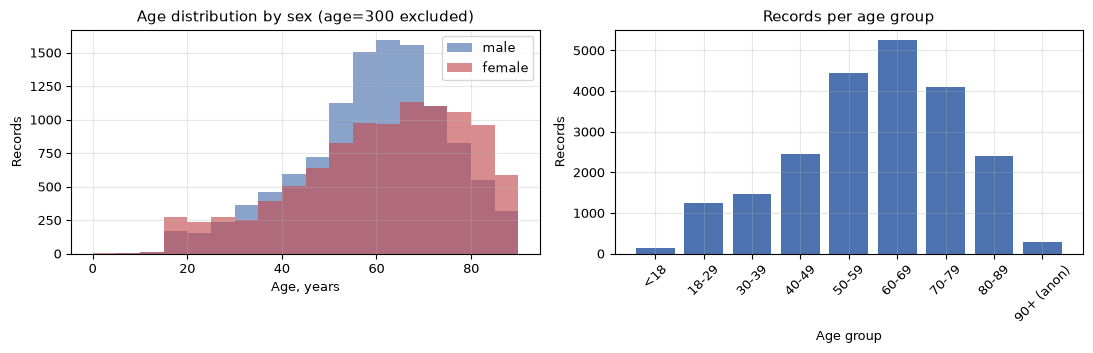

In [5]:
plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})
bins = [0, 18, 30, 40, 50, 60, 70, 80, 90]
labels = ['<18', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
age_bin = pd.cut(real_age, bins=bins, labels=labels, right=False)
group_counts = age_bin.value_counts().reindex(labels).tolist() + [int(anon.sum())]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for s, color in (('male', '#4C72B0'), ('female', '#C44E52')):
    ax[0].hist(df.loc[(~anon) & (df.sex_label == s), 'age'], bins=np.arange(0, 95, 5),
               alpha=0.65, label=s, color=color)
ax[0].set(xlabel='Age, years', ylabel='Records', title='Age distribution by sex (age=300 excluded)')
ax[0].legend()
ax[1].bar(labels + ['90+ (anon)'], group_counts, color='#4C72B0')
ax[1].set(xlabel='Age group', ylabel='Records', title='Records per age group')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [6]:
counts = Counter(c for cs in df.superclass for c in cs)
rows = []
for c in SUPERCLASSES:
    mask = df.superclass.apply(lambda v, c=c: c in v)
    rows.append({
        'class': c,
        'n': int(mask.sum()),
        'share_%': round(mask.mean() * 100, 1),
        'age_mean': round(df.loc[mask & (~anon), 'age'].mean(), 1),
        'female_%': round((df.loc[mask, 'sex_label'] == 'female').mean() * 100, 1),
    })
summary = pd.DataFrame(rows).set_index('class')
print(summary)
print(f"\nбез суперкласса: {df.superclass.apply(len).eq(0).sum()} "
      f"({df.superclass.apply(len).eq(0).mean()*100:.1f}%)")
print(f"мультиметка (>1 суперкласса): {df.superclass.apply(len).gt(1).sum()} "
      f"({df.superclass.apply(len).gt(1).mean()*100:.1f}%)")
print(f"доля female по датасету в целом: {(df.sex_label == 'female').mean()*100:.1f}%")

          n  share_%  age_mean  female_%
class                                   
NORM   9514     43.6      52.1      53.9
MI     5469     25.1      66.3      37.7
STTC   5235     24.0      66.3      51.0
CD     4898     22.5      65.3      38.8
HYP    2649     12.2      65.9      42.6

без суперкласса: 411 (1.9%)
мультиметка (>1 суперкласса): 5144 (23.6%)
доля female по датасету в целом: 47.9%


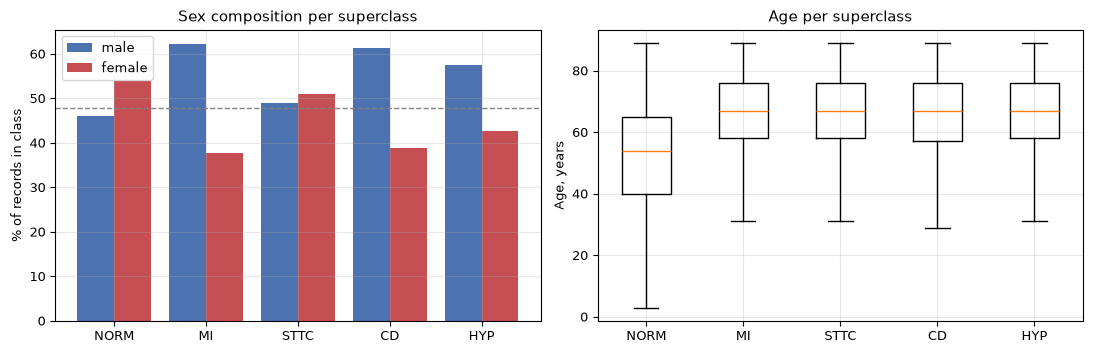

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
x = np.arange(len(SUPERCLASSES))
fem = summary['female_%'].tolist()
ax[0].bar(x - 0.2, [100 - f for f in fem], 0.4, label='male', color='#4C72B0')
ax[0].bar(x + 0.2, fem, 0.4, label='female', color='#C44E52')
ax[0].axhline((df.sex_label == 'female').mean() * 100, ls='--', c='gray', lw=1)
ax[0].set_xticks(x, SUPERCLASSES)
ax[0].set(ylabel='% of records in class', title='Sex composition per superclass')
ax[0].legend()
ax[1].boxplot([df.loc[df.superclass.apply(lambda v, c=c: c in v) & (~anon), 'age']
               for c in SUPERCLASSES], tick_labels=SUPERCLASSES, showfliers=False)
ax[1].set(ylabel='Age, years', title='Age per superclass')
plt.tight_layout()
plt.show()

In [8]:
# Технические поля, которые влияют на дизайн экспериментов
print(f'покрытие height: {df.height.notna().mean()*100:.1f}%, weight: {df.weight.notna().mean()*100:.1f}%, '
      f'heart_axis: {df.heart_axis.notna().mean()*100:.1f}%')
print(f'validated_by_human = True: {df.validated_by_human.mean()*100:.1f}% '
      f'(остальные {(~df.validated_by_human).sum()} записей — автоматическая интерпретация)')
print(f'устройств: {df.device.nunique()}, центров (site): {df.site.nunique()}, '
      f'период записи: {pd.to_datetime(df.recording_date).min().date()} — '
      f'{pd.to_datetime(df.recording_date).max().date()}')

# Проверка утечки пациентов между официальными фолдами
fold_span = df.groupby('patient_id').strat_fold.nunique()
print(f'пациентов, попавших более чем в один strat_fold: {(fold_span > 1).sum()} '
      f'(0 означает, что официальное разбиение можно использовать как есть)')

покрытие height: 32.0%, weight: 43.2%, heart_axis: 61.2%
validated_by_human = True: 73.7% (остальные 5743 записей — автоматическая интерпретация)
устройств: 11, центров (site): 51, период записи: 1984-11-09 — 2001-06-11
пациентов, попавших более чем в один strat_fold: 0 (0 означает, что официальное разбиение можно использовать как есть)


## Задача 2. Оценка качества сигналов

Считаем по случайной подвыборке из 500 записей (`random_state=42`) на 100 Гц. Метрики:

- **дрейф изолинии** — доля мощности отведения в полосе 0.01–0.5 Гц;
- **высокочастотный шум** — доля мощности в полосе 30–49 Гц (ЭМГ, наводка аппаратуры);
- **плоские участки** — максимальная доля отведения, занятая константой;
- **мёртвые отведения** — размах менее 0.05 мВ.

PTB-XL содержит собственную врачебную разметку помех (`baseline_drift`, `static_noise`,
`burst_noise`, `electrodes_problems`), поэтому автоматические метрики можно проверить на согласие
с ней, а не просто задать пороги «на глаз».

In [9]:
N_SUBSET = 500
FS_LR = 100
BASELINE_BAND = (0.01, 0.5)
HF_BAND = (30.0, 49.0)
DRIFT_FLAG, HF_FLAG, FLAT_FLAG = 0.30, 0.08, 0.20

sub = df.sample(n=N_SUBSET, random_state=SEED).sort_index()


def band_share(psd, freqs, lo, hi):
    total = np.trapezoid(psd, freqs)
    if total <= 0:
        return 0.0
    m = (freqs >= lo) & (freqs <= hi)
    return float(np.trapezoid(psd[m], freqs[m]) / total)


def longest_constant_run(x):
    flat = np.abs(np.diff(x)) < 1e-9
    best = run = 0
    for v in flat:
        run = run + 1 if v else 0
        best = max(best, run)
    return (best + 1) / len(x)


rows = []
for ecg_id, rec in sub.iterrows():
    sig, meta = wfdb.rdsamp(DATA_PATH + rec.filename_lr)
    nan_frac = float(np.isnan(sig).mean())
    sig = np.nan_to_num(sig)

    drift, hf, flat, p2p = [], [], [], []
    for i in range(sig.shape[1]):
        freqs, psd = welch(sig[:, i], fs=FS_LR, nperseg=min(512, sig.shape[0]))
        drift.append(band_share(psd, freqs, *BASELINE_BAND))
        hf.append(band_share(psd, freqs, *HF_BAND))
        flat.append(longest_constant_run(sig[:, i]))
        p2p.append(float(sig[:, i].max() - sig[:, i].min()))

    rows.append({'ecg_id': ecg_id, 'nan_frac': nan_frac,
                 'drift_max': max(drift), 'hf_max': max(hf),
                 'flat_max': max(flat), 'p2p_max': max(p2p), 'p2p_min': min(p2p)})

q = pd.DataFrame(rows).set_index('ecg_id')
q['flag_drift'] = q.drift_max > DRIFT_FLAG
q['flag_hf'] = q.hf_max > HF_FLAG
q['flag_flat'] = q.flat_max > FLAT_FLAG
q['flag_nan'] = q.nan_frac > 0
q['flag_lowamp'] = q.p2p_min < 0.05
q['flag_any'] = q[['flag_drift', 'flag_hf', 'flag_flat', 'flag_nan', 'flag_lowamp']].any(axis=1)

print(q[['flag_drift', 'flag_hf', 'flag_flat', 'flag_nan', 'flag_lowamp', 'flag_any']].sum())
print(f'\nзаписей хотя бы с одним флагом: {q.flag_any.sum()} ({q.flag_any.mean()*100:.1f}%)')
print(f'дрейф (доля мощности 0.01-0.5 Гц): median={q.drift_max.median():.3f}, '
      f'p90={q.drift_max.quantile(0.9):.3f}, max={q.drift_max.max():.3f}')
print(f'ВЧ-шум (доля мощности 30-49 Гц): median={q.hf_max.median():.4f}, '
      f'p90={q.hf_max.quantile(0.9):.4f}, max={q.hf_max.max():.4f}')
print(f'размах максимального отведения, мВ: median={q.p2p_max.median():.2f}, '
      f'max={q.p2p_max.max():.2f}')

flag_drift      54
flag_hf         76
flag_flat        0
flag_nan         0
flag_lowamp      0
flag_any       126
dtype: int64

записей хотя бы с одним флагом: 126 (25.2%)
дрейф (доля мощности 0.01-0.5 Гц): median=0.073, p90=0.307, max=0.485
ВЧ-шум (доля мощности 30-49 Гц): median=0.0391, p90=0.0888, max=0.2639
размах максимального отведения, мВ: median=2.56, max=15.07


In [10]:
# Согласие автоматических метрик с врачебной разметкой помех
ann_drift = sub.baseline_drift.notna()
ann_static = sub.static_noise.notna()
ann_any = (ann_drift | ann_static | sub.burst_noise.notna() | sub.electrodes_problems.notna())

print(f'размечено врачом как помеха: baseline_drift {ann_drift.sum()}, '
      f'static_noise {ann_static.sum()}, burst_noise {sub.burst_noise.notna().sum()}, '
      f'electrodes_problems {sub.electrodes_problems.notna().sum()}; '
      f'хотя бы одна пометка — {ann_any.sum()} ({ann_any.mean()*100:.1f}%)')

p_drift = mannwhitneyu(q.loc[ann_drift, 'drift_max'], q.loc[~ann_drift, 'drift_max']).pvalue
p_static = mannwhitneyu(q.loc[ann_static, 'hf_max'], q.loc[~ann_static, 'hf_max']).pvalue
print(f'\nдрейф: median {q.loc[ann_drift, "drift_max"].median():.3f} у размеченных против '
      f'{q.loc[~ann_drift, "drift_max"].median():.3f} у остальных, p = {p_drift:.2e}')
print(f'ВЧ-шум: median {q.loc[ann_static, "hf_max"].median():.4f} у размеченных static_noise против '
      f'{q.loc[~ann_static, "hf_max"].median():.4f} у остальных, p = {p_static:.3f}')

размечено врачом как помеха: baseline_drift 35, static_noise 87, burst_noise 20, electrodes_problems 1; хотя бы одна пометка — 129 (25.8%)

дрейф: median 0.303 у размеченных против 0.060 у остальных, p = 4.49e-13
ВЧ-шум: median 0.0372 у размеченных static_noise против 0.0395 у остальных, p = 0.845


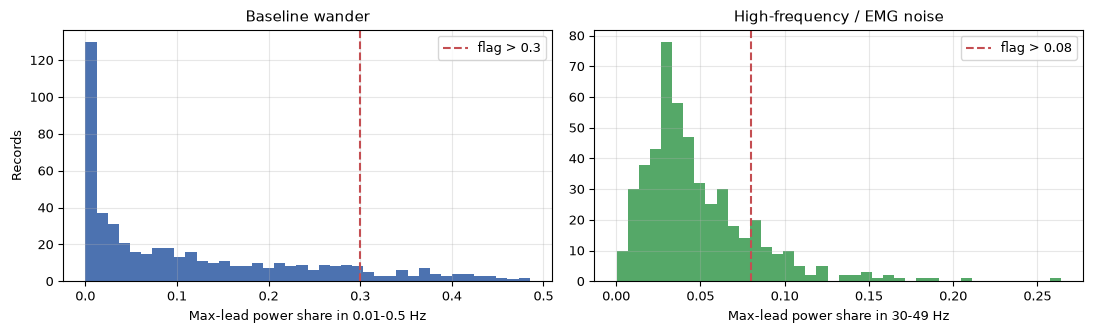

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(q.drift_max, bins=40, color='#4C72B0')
ax[0].axvline(DRIFT_FLAG, color='#C44E52', ls='--', label=f'flag > {DRIFT_FLAG}')
ax[0].set(xlabel='Max-lead power share in 0.01-0.5 Hz', ylabel='Records', title='Baseline wander')
ax[0].legend()
ax[1].hist(q.hf_max, bins=40, color='#55A868')
ax[1].axvline(HF_FLAG, color='#C44E52', ls='--', label=f'flag > {HF_FLAG}')
ax[1].set(xlabel='Max-lead power share in 30-49 Hz', title='High-frequency / EMG noise')
ax[1].legend()
plt.tight_layout()
plt.show()

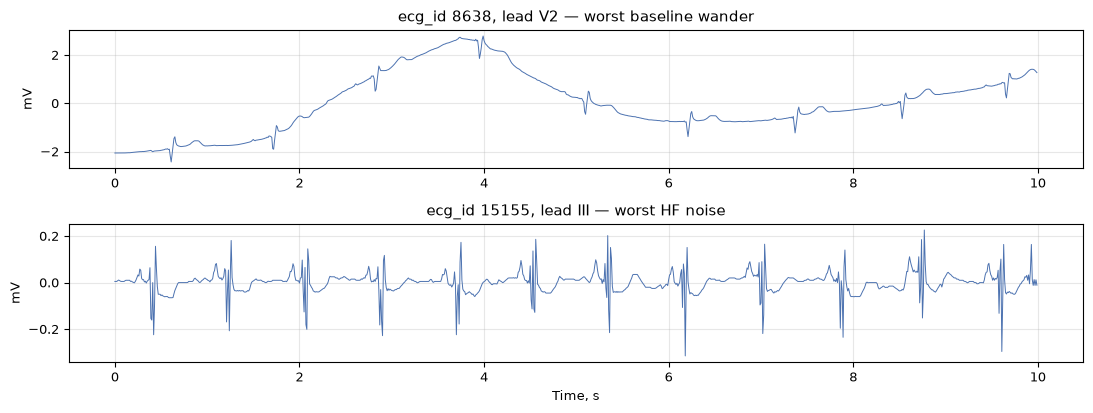

In [12]:
# Примеры проблемных записей: худшая по дрейфу и худшая по ВЧ-шуму
fig, ax = plt.subplots(2, 1, figsize=(11, 4.2))
for a, rid, title, band in ((ax[0], q.drift_max.idxmax(), 'worst baseline wander', BASELINE_BAND),
                            (ax[1], q.hf_max.idxmax(), 'worst HF noise', HF_BAND)):
    s, m = wfdb.rdsamp(DATA_PATH + sub.loc[rid].filename_lr)
    s = np.nan_to_num(s)
    shares = []
    for i in range(s.shape[1]):
        freqs, psd = welch(s[:, i], fs=FS_LR, nperseg=512)
        shares.append(band_share(psd, freqs, *band))
    lead = int(np.argmax(shares))
    a.plot(np.arange(len(s)) / FS_LR, s[:, lead], lw=0.7, color='#4C72B0')
    a.set(title=f'ecg_id {rid}, lead {m["sig_name"][lead]} — {title}', ylabel='mV')
ax[1].set_xlabel('Time, s')
plt.tight_layout()
plt.show()

## Задача 3. records100 против records500

Берём 150 записей из той же подвыборки и сравниваем обе версии сигнала поотведенчески (1800 отведений):

- сколько мощности лежит выше 50 Гц, то есть теряется при переходе на 100 Гц;
- насколько 500 Гц, приведённые к 100 Гц (`decimate`, FIR, zero-phase), совпадают с готовым `records100`;
- проявляется ли выше 50 Гц та самая разметка `static_noise`, которую на 100 Гц обнаружить не удалось;
- цена хранения и чтения.

In [13]:
N_HR = 150
FS_HR = 500
NYQ_LR = FS_LR / 2
POWERLINE = (49.0, 51.0)
TRIM = 5          # краевой переходный процесс FIR-фильтра
MISMATCH = 2.0    # расхождение версий по RMS или пику более чем в 2 раза

hr_sub = sub.sample(n=N_HR, random_state=SEED).sort_index()


def ratio(a, b):
    return max(a, b) / min(a, b) if min(a, b) > 0 else np.inf


leads = []
for ecg_id, rec in hr_sub.iterrows():
    hr, meta = wfdb.rdsamp(DATA_PATH + rec.filename_hr)
    lr, _ = wfdb.rdsamp(DATA_PATH + rec.filename_lr)
    hr, lr = np.nan_to_num(hr), np.nan_to_num(lr)

    for i in range(hr.shape[1]):
        f, p = welch(hr[:, i], fs=FS_HR, nperseg=1024)
        down = decimate(hr[:, i], FS_HR // FS_LR, ftype='fir', zero_phase=True)
        n = min(len(down), len(lr))
        a, b = down[TRIM:n - TRIM], lr[TRIM:n - TRIM, i]
        rms_a, rms_b = np.sqrt(np.mean(a ** 2)), np.sqrt(np.mean(b ** 2))
        leads.append({
            'ecg_id': ecg_id, 'lead': meta['sig_name'][i],
            'above50': band_share(p, f, NYQ_LR, FS_HR / 2),
            'mains': band_share(p, f, *POWERLINE),
            'corr': float(np.corrcoef(a, b)[0, 1]),
            'nrmse': float(np.sqrt(np.mean((a - b) ** 2)) / rms_b),
            'rms_ratio': ratio(float(rms_a), float(rms_b)),
            'peak_ratio': ratio(float(np.abs(hr[:, i]).max()), float(np.abs(lr[:, i]).max())),
        })

L = pd.DataFrame(leads)
L['mismatch'] = (L.rms_ratio > MISMATCH) | (L.peak_ratio > MISMATCH)
clean = L[~L.mismatch]

print(f'мощность выше 50 Гц: mean={L.above50.mean()*100:.2f}%, median={L.above50.median()*100:.2f}%, '
      f'p95={L.above50.quantile(0.95)*100:.2f}%, max={L.above50.max()*100:.2f}%')
print(f'совпадение 500->100 Гц с records100: corr mean={clean["corr"].mean():.4f}, '
      f'p05={clean["corr"].quantile(0.05):.4f}, min={clean["corr"].min():.4f}')
print(f'NRMSE: median={clean.nrmse.median()*100:.2f}%, p95={clean.nrmse.quantile(0.95)*100:.2f}%')
print(f'расхождение версий (артефакт только в одной из них): {L.mismatch.sum()} отведений '
      f'из {len(L)} ({L.mismatch.mean()*100:.2f}%) в {L[L.mismatch].ecg_id.nunique()} записях')

мощность выше 50 Гц: mean=0.68%, median=0.34%, p95=2.29%, max=11.59%
совпадение 500->100 Гц с records100: corr mean=0.9927, p05=0.9771, min=0.8754
NRMSE: median=9.81%, p95=21.39%
расхождение версий (артефакт только в одной из них): 7 отведений из 1800 (0.39%) в 3 записях


In [14]:
# Где именно расходятся версии
for _, r in L[L.mismatch].iterrows():
    hr, meta = wfdb.rdsamp(DATA_PATH + hr_sub.loc[r.ecg_id].filename_hr)
    lr, _ = wfdb.rdsamp(DATA_PATH + hr_sub.loc[r.ecg_id].filename_lr)
    j = meta['sig_name'].index(r.lead)
    t_hr = float(np.abs(np.nan_to_num(hr)[:, j]).argmax()) / FS_HR
    t_lr = float(np.abs(np.nan_to_num(lr)[:, j]).argmax()) / FS_LR
    print(f'ecg_id {r.ecg_id:6d} {r.lead:4s}: пик в records500 на {t_hr:.2f} с, '
          f'в records100 на {t_lr:.2f} с')

ecg_id   8540 V6  : пик в records500 на 5.06 с, в records100 на 9.99 с
ecg_id  13317 I   : пик в records500 на 9.89 с, в records100 на 4.42 с
ecg_id  13317 III : пик в records500 на 9.89 с, в records100 на 1.52 с
ecg_id  13317 AVR : пик в records500 на 9.89 с, в records100 на 6.35 с
ecg_id  13317 AVL : пик в records500 на 9.89 с, в records100 на 5.37 с
ecg_id  13317 AVF : пик в records500 на 9.89 с, в records100 на 6.35 с
ecg_id  20980 II  : пик в records500 на 9.52 с, в records100 на 9.93 с


In [15]:
per_rec = L.groupby('ecg_id').agg(above50_mean=('above50', 'mean'), mains_max=('mains', 'max'))
ann_static_hr = hr_sub.static_noise.notna()

p_mains = mannwhitneyu(per_rec.loc[ann_static_hr, 'mains_max'],
                       per_rec.loc[~ann_static_hr, 'mains_max']).pvalue
p_above = mannwhitneyu(per_rec.loc[ann_static_hr, 'above50_mean'],
                       per_rec.loc[~ann_static_hr, 'above50_mean']).pvalue
print(f'наводка 49-51 Гц: median {per_rec.loc[ann_static_hr, "mains_max"].median():.5f} у записей с '
      f'static_noise против {per_rec.loc[~ann_static_hr, "mains_max"].median():.5f}, p = {p_mains:.3f}')
print(f'мощность выше 50 Гц: median {per_rec.loc[ann_static_hr, "above50_mean"].median():.5f} против '
      f'{per_rec.loc[~ann_static_hr, "above50_mean"].median():.5f}, p = {p_above:.4f}')

size_lr = sum(os.path.getsize(DATA_PATH + hr_sub.loc[i].filename_lr + '.dat') for i in per_rec.index)
size_hr = sum(os.path.getsize(DATA_PATH + hr_sub.loc[i].filename_hr + '.dat') for i in per_rec.index)


def load_seconds(col):
    t0 = time.perf_counter()
    for i in per_rec.index:
        wfdb.rdsamp(DATA_PATH + hr_sub.loc[i, col])
    return time.perf_counter() - t0


print(f'\nобъём {N_HR} записей: 100 Гц {size_lr/1e6:.1f} МБ, 500 Гц {size_hr/1e6:.1f} МБ '
      f'(x{size_hr/size_lr:.1f}); весь датасет — {21799*24000/1024**3:.2f} ГБ против '
      f'{21799*120000/1024**3:.2f} ГБ')
print(f'чтение с диска: 100 Гц {load_seconds("filename_lr"):.2f} с, '
      f'500 Гц {load_seconds("filename_hr"):.2f} с')
print(f'разрешение по времени: 10 мс против 2 мс на отсчёт')

наводка 49-51 Гц: median 0.00144 у записей с static_noise против 0.00142, p = 0.978
мощность выше 50 Гц: median 0.00642 против 0.00489, p = 0.0145

объём 150 записей: 100 Гц 3.6 МБ, 500 Гц 18.0 МБ (x5.0); весь датасет — 0.49 ГБ против 2.44 ГБ


чтение с диска: 100 Гц 0.63 с, 500 Гц 0.82 с
разрешение по времени: 10 мс против 2 мс на отсчёт


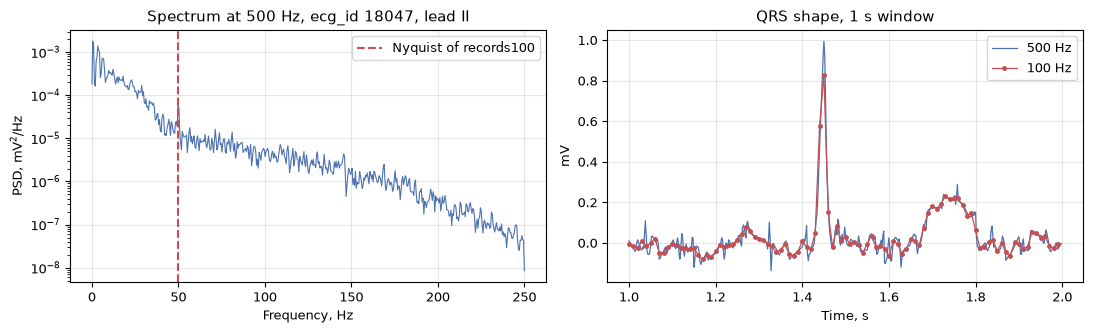

In [16]:
example = int(per_rec.above50_mean.idxmax())
hr, meta = wfdb.rdsamp(DATA_PATH + hr_sub.loc[example].filename_hr)
lr, _ = wfdb.rdsamp(DATA_PATH + hr_sub.loc[example].filename_lr)
hr, lr = np.nan_to_num(hr), np.nan_to_num(lr)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
f, p = welch(hr[:, 1], fs=FS_HR, nperseg=1024)
ax[0].semilogy(f, p, lw=0.8, color='#4C72B0')
ax[0].axvline(NYQ_LR, color='#C44E52', ls='--', label='Nyquist of records100')
ax[0].set(xlabel='Frequency, Hz', ylabel='PSD, mV$^2$/Hz',
          title=f'Spectrum at 500 Hz, ecg_id {example}, lead II')
ax[0].legend()

t_hr, t_lr = np.arange(len(hr)) / FS_HR, np.arange(len(lr)) / FS_LR
m_hr, m_lr = (t_hr >= 1.0) & (t_hr < 2.0), (t_lr >= 1.0) & (t_lr < 2.0)
ax[1].plot(t_hr[m_hr], hr[m_hr, 1], lw=0.9, color='#4C72B0', label='500 Hz')
ax[1].plot(t_lr[m_lr], lr[m_lr, 1], lw=0.9, color='#C44E52', marker='o', ms=2.5, label='100 Hz')
ax[1].set(xlabel='Time, s', ylabel='mV', title='QRS shape, 1 s window')
ax[1].legend()
plt.tight_layout()
plt.show()

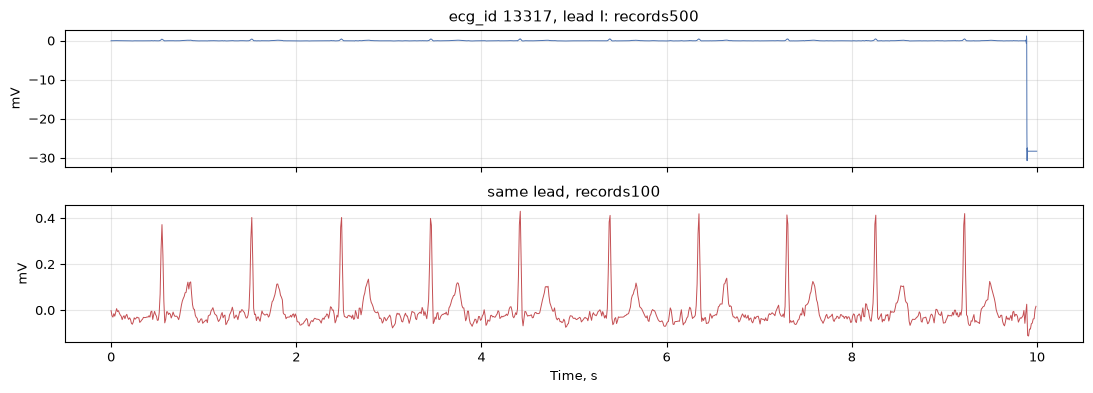

In [17]:
bad_id = int(L[L.mismatch].ecg_id.value_counts().idxmax())
bad_lead = L[(L.ecg_id == bad_id) & L.mismatch].iloc[0].lead
hr, meta = wfdb.rdsamp(DATA_PATH + hr_sub.loc[bad_id].filename_hr)
lr, _ = wfdb.rdsamp(DATA_PATH + hr_sub.loc[bad_id].filename_lr)
j = meta['sig_name'].index(bad_lead)

fig, ax = plt.subplots(2, 1, figsize=(11, 4.0), sharex=True)
ax[0].plot(np.arange(len(hr)) / FS_HR, np.nan_to_num(hr)[:, j], lw=0.7, color='#4C72B0')
ax[0].set(title=f'ecg_id {bad_id}, lead {bad_lead}: records500', ylabel='mV')
ax[1].plot(np.arange(len(lr)) / FS_LR, np.nan_to_num(lr)[:, j], lw=0.7, color='#C44E52')
ax[1].set(title='same lead, records100', ylabel='mV', xlabel='Time, s')
plt.tight_layout()
plt.show()

## Выводы недели 2

**Демография.** 21 799 записей от 18 869 пациентов, 52.1 % мужчин. Медианный возраст 61 год,
1.34 % записей имеют `age = 300` (анонимизация 90+) — их нужно отсеивать или выносить в отдельную
категорию, иначе среднее возраста смещается с 59.5 до 62.8 года. Классы различаются демографически:
NORM — 52.1 года и 53.9 % женщин, MI — 66.3 года и всего 37.7 % женщин. Это прямое продолжение
результата года 1 (гендерная асимметрия признаков на Cleveland): на PTB-XL пол и возраст
конфаундированы с диагнозом, поэтому оценивать модель нужно отдельно по полу.

**Качество сигналов.** Из 500 записей 25.2 % получили хотя бы один автоматический флаг; в самих
метаданных PTB-XL помехи размечены врачом у 25.8 % записей — цифры сошлись. Метрика дрейфа
изолинии согласуется с разметкой `baseline_drift` (0.303 против 0.060, p ≈ 4e-13), а вот полоса
30–49 Гц с разметкой `static_noise` не связана вообще (p = 0.85). NaN, плоских и мёртвых отведений
на 100 Гц не найдено.

**Частота дискретизации.** Выше 50 Гц лежит в среднем 0.68 % мощности сигнала (p95 = 2.29 %),
приведение 500 → 100 Гц воспроизводит `records100` с corr = 0.993 и NRMSE ≈ 10 %. При этом
`static_noise` статистически проявляется именно выше 50 Гц (p = 0.014), то есть на 100 Гц эта
помеха принципиально ненаблюдаема. Наводка 49–51 Гц отсутствует в обеих версиях (p = 0.98) —
датасет уже отфильтрован, режекторный фильтр в препроцессинге не нужен.

**Решение:** основной формат обучения — `records100`. 500 Гц дороже в 5 раз по объёму (2.44 ГБ
против 0.49 ГБ) и даёт менее 1 % дополнительной мощности сигнала; `records500` оставляем для
контроля качества и для будущих задач, где важна морфология QRS (разрешение 2 мс против 10 мс).

**Побочная находка.** 7 отведений из 1800 (3 записи) расходятся между версиями более чем вдвое по
амплитуде, и все расхождения приходятся на последние 0.5 с записи — переходные артефакты конца
регистрации, присутствующие только в одной из версий. Практический вывод: обрезать края и брать
окно 0.5–9.5 с.

## План на неделю 3

1. Препроцессинг-пайплайн: фильтрация 0.5–40 Гц, нормализация по отведениям, обрезка краёв,
   формирование тензоров для обучения.
2. Разбиение по официальному `strat_fold` (проверено: утечки пациентов между фолдами нет).
3. Baseline-модель 1D-CNN на `records100`, метрика macro-AUC по 5 суперклассам.